# 1.2. Thống kê mô tả

Phân tích thống kê mô tả cho tập dữ liệu **Heart Disease Dataset**:
- Các chỉ số: mean, median, std, min, max, quartiles...
- Biểu đồ phân phối
- Ma trận tương quan

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

DATA_PATH = Path("dataset/heart.csv")
df = pd.read_csv(DATA_PATH)

# Phân loại thuộc tính: liên tục vs định tính (để mô tả phù hợp)
CONT_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CAT_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

## Thống kê mô tả các biến liên tục (Mean, Median, Std, ...)

In [3]:
thong_ke = df[CONT_COLS].describe().T
thong_ke = thong_ke.rename(columns={
    "count": "Số lượng",
    "mean": "Mean (Trung bình)",
    "std": "Std (Độ lệch chuẩn)",
    "min": "Giá trị nhỏ nhất",
    "25%": "Q1 (25%)",
    "50%": "Median (Trung vị)",
    "75%": "Q3 (75%)",
    "max": "Giá trị lớn nhất",
})
display(thong_ke.round(4))

,Số lượng,Mean (Trung bình),Std (Độ lệch chuẩn),Giá trị nhỏ nhất,Q1 (25%),Median (Trung vị),Q3 (75%),Giá trị lớn nhất
age,1025.0,54.4341,9.0723,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.6117,17.5167,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.0000,51.5925,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.1141,23.0057,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.0715,1.1751,0.0,0.0,0.8,1.8,6.2


In [4]:
# Bổ sung: phương sai, độ lệch, độ nhọn, khoảng biến thiên
bo_sung = pd.DataFrame({
    "Phương sai (Variance)": df[CONT_COLS].var(),
    "Độ lệch (Skewness)": df[CONT_COLS].skew(),
    "Độ nhọn (Kurtosis)": df[CONT_COLS].kurtosis(),
    "Khoảng biến thiên (Range)": df[CONT_COLS].max() - df[CONT_COLS].min(),
})
display(bo_sung.round(4))

,Phương sai (Variance),Độ lệch (Skewness),Độ nhọn (Kurtosis),Khoảng biến thiên (Range)
age,82.3065,-0.2489,-0.5256,48.0
trestbps,306.8354,0.7398,0.9912,106.0
chol,2661.7871,1.0741,3.9968,438.0
thalach,529.2633,-0.5138,-0.0888,131.0
oldpeak,1.3808,1.2109,1.3145,6.2


## Thống kê mô tả các biến định tính (tần số)

In [5]:
for col in CAT_COLS:
    tan_so = df[col].value_counts().sort_index()
    ty_le = (df[col].value_counts(normalize=True).sort_index() * 100).round(2)
    bang = pd.DataFrame({"Tần số": tan_so, "Tỉ lệ (%)": ty_le})
    print(f"— Thuộc tính: {col}")
    display(bang)

— Thuộc tính: sex


,Tần số,Tỉ lệ (%)
sex,,
0,312,30.44
1,713,69.56


— Thuộc tính: cp


,Tần số,Tỉ lệ (%)
cp,,
0,497,48.49
1,167,16.29
2,284,27.71
3,77,7.51


— Thuộc tính: fbs


...

,Tần số,Tỉ lệ (%)
ca,,
0,578,56.39
1,226,22.05
2,134,13.07
3,69,6.73
4,18,1.76


— Thuộc tính: thal


,Tần số,Tỉ lệ (%)
thal,,
0,7,0.68
1,64,6.24
2,544,53.07
3,410,40.00


— Thuộc tính: target


,Tần số,Tỉ lệ (%)
target,,
0,499,48.68
1,526,51.32


## Biểu đồ phân phối các biến liên tục

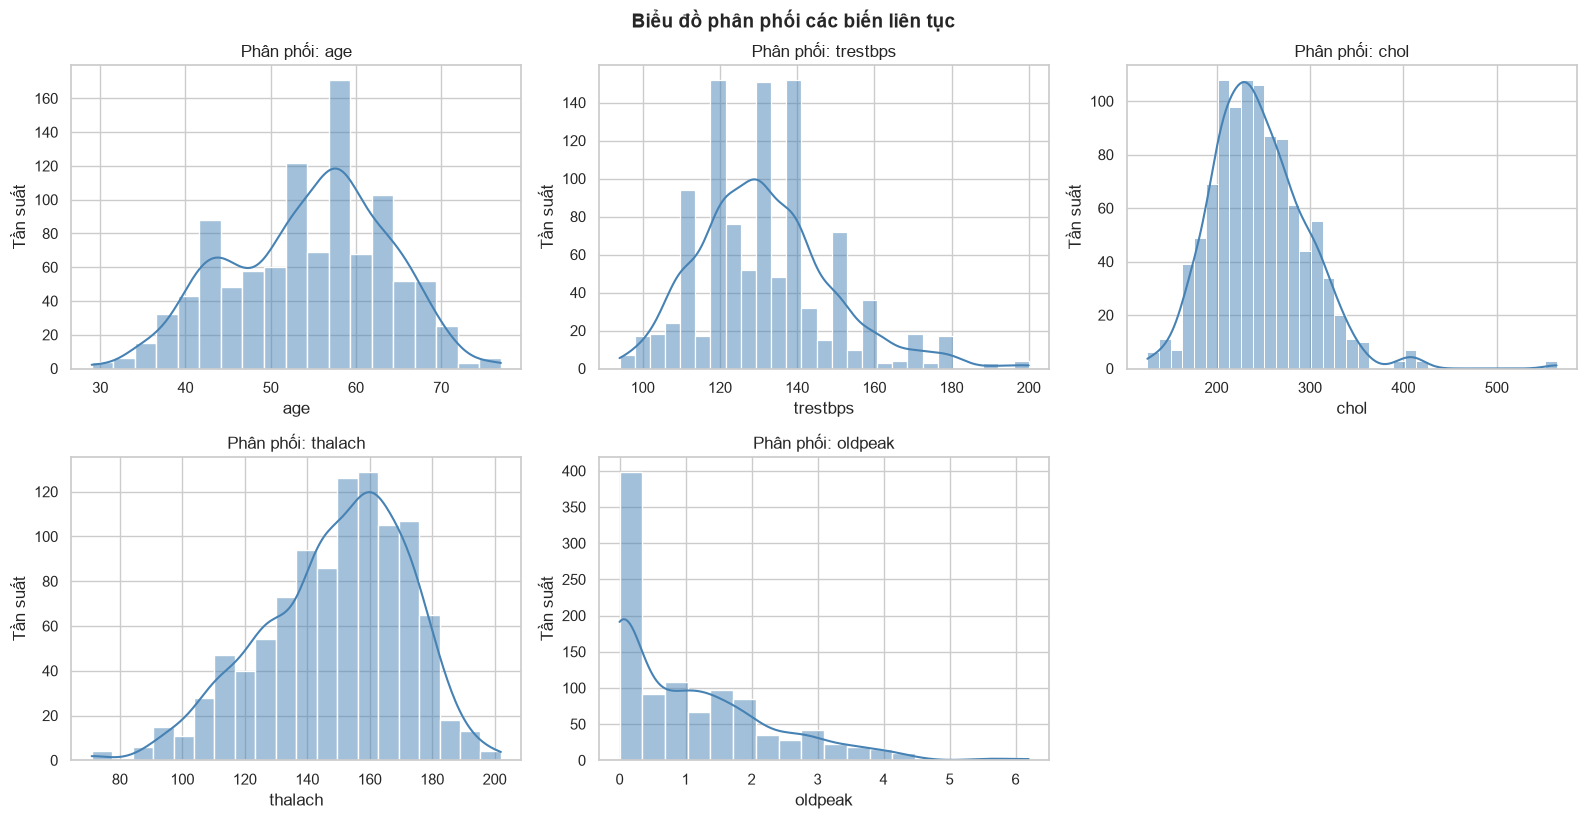

In [6]:
n_cols = 3
n_rows = int(np.ceil(len(CONT_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(CONT_COLS):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(f"Phân phối: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")
for j in range(len(CONT_COLS), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.suptitle("Biểu đồ phân phối các biến liên tục", y=1.02, fontsize=14, fontweight="bold")
plt.show()

## Phân phối biến mục tiêu (target)

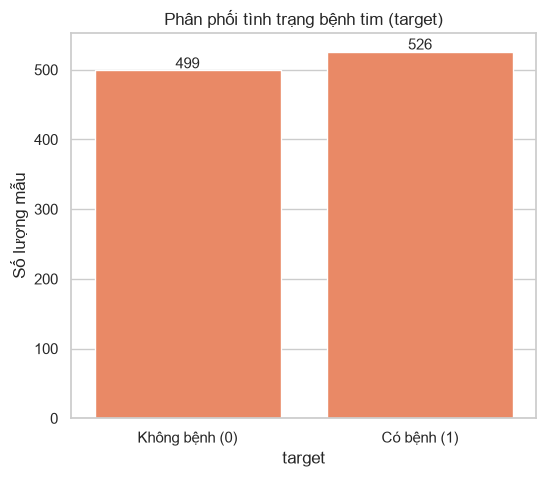

In [7]:
plt.figure(figsize=(6, 5))
target_counts = df["target"].value_counts().sort_index()
ax = sns.barplot(x=target_counts.index, y=target_counts.values, color="coral", edgecolor="white")
ax.set_xticks(range(len(target_counts)))
ax.set_xticklabels(["Không bệnh (0)", "Có bệnh (1)"])
plt.title("Phân phối tình trạng bệnh tim (target)")
plt.xlabel("target")
plt.ylabel("Số lượng mẫu")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 3, str(v), ha="center")
plt.show()

## Boxplot các biến liên tục theo tình trạng bệnh

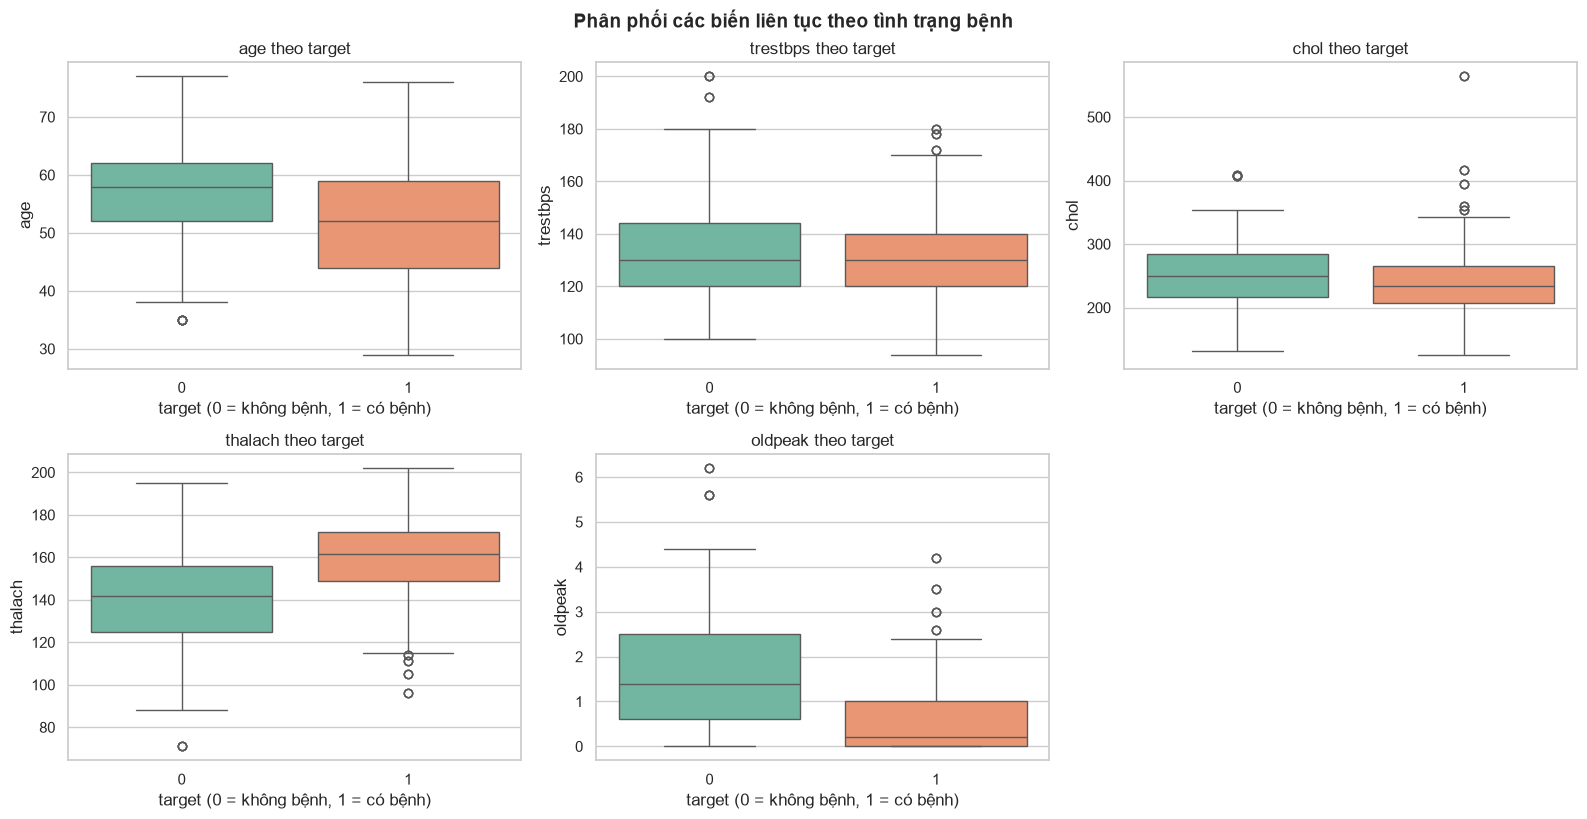

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(CONT_COLS):
    sns.boxplot(data=df, x="target", y=col, hue="target", palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(f"{col} theo target")
    axes[i].set_xlabel("target (0 = không bệnh, 1 = có bệnh)")
    axes[i].set_ylabel(col)
for j in range(len(CONT_COLS), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.suptitle("Phân phối các biến liên tục theo tình trạng bệnh", y=1.02, fontsize=14, fontweight="bold")
plt.show()

## Ma trận tương quan

In [9]:
corr_matrix = df.corr(numeric_only=True)
display(corr_matrix.round(4))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.0000,-0.1032,-0.0720,0.2711,0.2198,0.1212,-0.1327,-0.3902,0.0882,0.2081,-0.1691,0.2716,0.0723,-0.2293
sex,-0.1032,1.0000,-0.0411,-0.0790,-0.1983,0.0272,-0.0551,-0.0494,0.1392,0.0847,-0.0267,0.1117,0.1984,-0.2795
cp,-0.0720,-0.0411,1.0000,0.0382,-0.0816,0.0793,0.0436,0.3068,-0.4015,-0.1747,0.1316,-0.1762,-0.1633,0.4349
trestbps,0.2711,-0.0790,0.0382,1.0000,0.1280,0.1818,-0.1238,-0.0393,0.0612,0.1874,-0.1204,0.1046,0.0593,-0.1388
chol,0.2198,-0.1983,-0.0816,0.1280,1.0000,0.0269,-0.1474,-0.0218,0.0674,0.0649,-0.0142,0.0743,0.1002,-0.1000
fbs,0.1212,0.0272,0.0793,0.1818,0.0269,1.0000,-0.1041,-0.0089,0.0493,0.0109,-0.0619,0.1372,-0.0422,-0.0412
restecg,-0.1327,-0.0551,0.0436,-0.1238,-0.1474,-0.1041,1.0000,0.0484,-0.0656,-0.0501,0.0861,-0.0781,-0.0205,0.1345
thalach,-0.3902,-0.0494,0.3068,-0.0393,-0.0218,-0.0089,0.0484,1.0000,-0.3803,-0.3498,0.3953,-0.2079,-0.0981,0.4229
exang,0.0882,0.1392,-0.4015,0.0612,0.0674,0.0493,-0.0656,-0.3803,1.0000,0.3108,-0.2673,0.1078,0.1972,-0.4380
oldpeak,0.2081,0.0847,-0.1747,0.1874,0.0649,0.0109,-0.0501,-0.3498,0.3108,1.0000,-0.5752,0.2218,0.2027,-0.4384


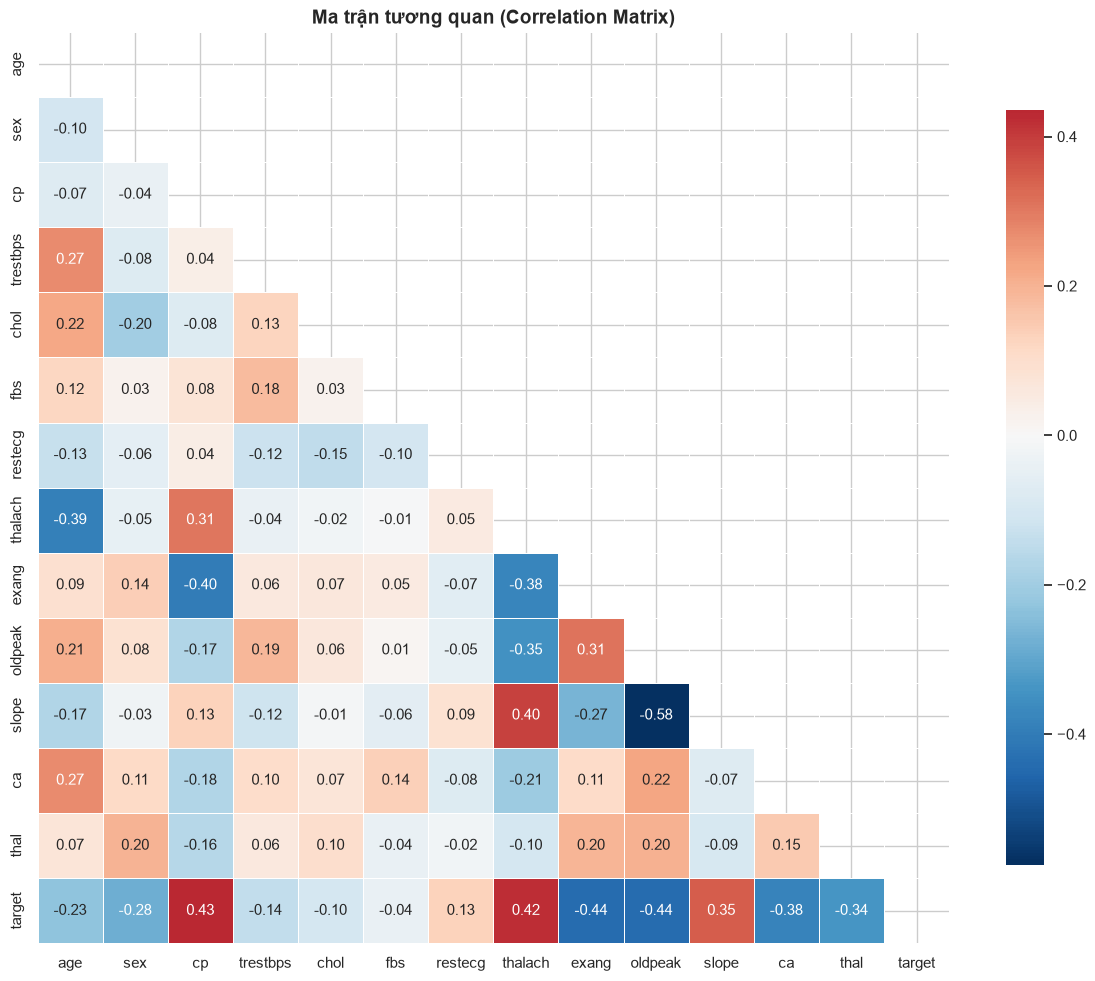

In [10]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Ma trận tương quan (Correlation Matrix)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

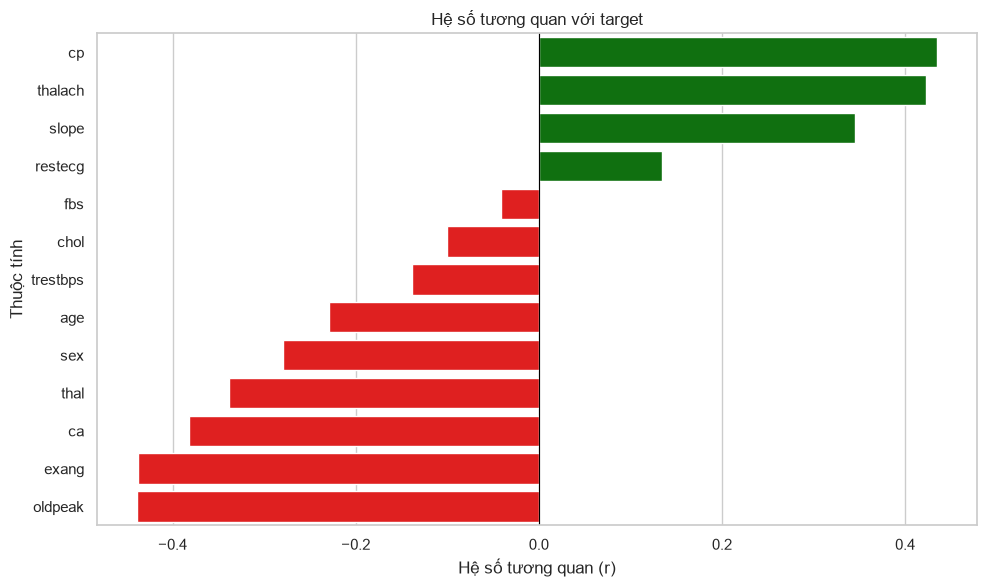


Tương quan với target (sắp xếp giảm dần):
  • cp: 0.4349
  • thalach: 0.4229
  • slope: 0.3455
  • restecg: 0.1345
  • fbs: -0.0412
  • chol: -0.1000
  • trestbps: -0.1388
  • age: -0.2293
  • sex: -0.2795
  • thal: -0.3378
  • ca: -0.3821
  • exang: -0.4380
  • oldpeak: -0.4384


In [11]:
# Tương quan với biến mục tiêu target
corr_target = corr_matrix["target"].drop("target").sort_values(ascending=False)
plt.figure(figsize=(10, 6))
colors = ["green" if v > 0 else "red" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=colors, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Hệ số tương quan với target")
plt.xlabel("Hệ số tương quan (r)")
plt.ylabel("Thuộc tính")
plt.tight_layout()
plt.show()

print("\nTương quan với target (sắp xếp giảm dần):")
for col, val in corr_target.items():
    print(f"  • {col}: {val:.4f}")

## Tóm tắt nhận xét

In [12]:
print("=" * 55)
print("TÓM TẮT THỐNG KÊ MÔ TẢ")
print("=" * 55)
print(f"\n• Số mẫu: {len(df):,}")
print(f"• Số biến liên tục: {len(CONT_COLS)} | Số biến định tính: {len(CAT_COLS)}")
print(f"• Tỉ lệ có bệnh: {(df['target']==1).mean()*100:.2f}%")

top_pos = corr_target.head(3)
top_neg = corr_target.tail(3).sort_values()
print("\n• Tương quan dương mạnh nhất với target:")
for col, val in top_pos.items():
    print(f"    - {col}: {val:.4f}")
print("\n• Tương quan âm mạnh nhất với target:")
for col, val in top_neg.items():
    print(f"    - {col}: {val:.4f}")

TÓM TẮT THỐNG KÊ MÔ TẢ

• Số mẫu: 1,025
• Số biến liên tục: 5 | Số biến định tính: 9
• Tỉ lệ có bệnh: 51.32%

• Tương quan dương mạnh nhất với target:
    - cp: 0.4349
    - thalach: 0.4229
    - slope: 0.3455

• Tương quan âm mạnh nhất với target:
    - oldpeak: -0.4384
    - exang: -0.4380
    - ca: -0.3821
